In [1]:
import yfinance as yf

df = yf.download(
    "AAPL",
    start="2020-01-01",
    end="2025-01-01"
)

print(df.head())

/tmp/ipykernel_2082/3125644530.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.333878  72.394086  71.091184  71.344054  135480400
2020-01-03  71.630630  72.389250  71.406659  71.563198  146322800
2020-01-06  72.201401  72.239935  70.503539  70.754006  118387200
2020-01-07  71.861877  72.466361  71.642719  72.211079  108872000
2020-01-08  73.017830  73.318870  71.565614  71.565614  132079200


In [2]:
X = df[['Open','High','Low','Volume']]

In [3]:
X

Price,Open,High,Low,Volume
Ticker,AAPL,AAPL,AAPL,AAPL
Date,,,,
2020-01-02,71.344054,72.394086,71.091184,135480400
2020-01-03,71.563198,72.389250,71.406659,146322800
2020-01-06,70.754006,72.239935,70.503539,118387200
2020-01-07,72.211079,72.466361,71.642719,108872000
2020-01-08,71.565614,73.318870,71.565614,132079200
...,...,...,...,...
2024-12-24,253.868050,256.570768,253.669307,23234700
2024-12-26,256.550893,258.448771,255.994450,27237100


In [4]:
df['Next_Close'] = df['Close'].shift(-1)

df = df.dropna()

In [5]:
y = df['Next_Close']

In [9]:
from sklearn.model_selection import train_test_split

X = df[['Open','High','Low','Volume']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [11]:
y_pred = model.predict(X_test)

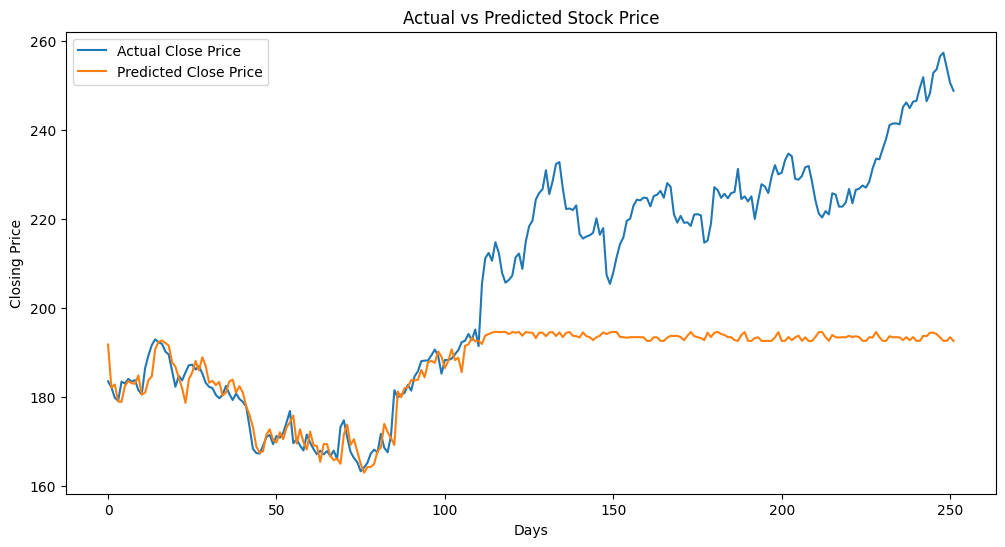

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values,
         label='Actual Close Price')

plt.plot(y_pred,
         label='Predicted Close Price')

plt.xlabel('Days')
plt.ylabel('Closing Price')
plt.title('Actual vs Predicted Stock Price')

plt.legend()
plt.show()

In [13]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 19.217270169333805


In [14]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)
print("R2 Percentage:", r2 * 100)

R2 Score: -0.033096369343399656
R2 Percentage: -3.3096369343399656
